# SE(3) invariant description

We propose in this paper a 3D face representation which is invariant under the transformations of the 𝑆𝐸(3) group and independent to the original mesh. We implement the 3D face description proposed by jribi et al. [2], which is based on the multipolar parameterization, on many regions of the face. Fig. 2 shows an overview of the proposed representation.
Thus, the multipolar geodesic parameterization is constructed on many parts of the face that correspond to the eyes and the nose (Fig. 2(a)). This fact makes the proposed representation independent with regard to the original mesh. The proposed description consists on computing the curvature fields on each parameterization (Fig. 2(b)). A step of dimensional reduction is performed in order to reduce the cardinality of the obtained description (Fig. 2(c)).

## 1. Find inner or outer eye corner and nose

Reference points should be chosen from the static zone, which is less influenced by the expression effects and corresponds to the nose, the eyes and the forehead. The other parts of the face are considered as mimic. Jribi et al. use the nose and the two eyes as interest regions.

In Jribi et al. (2019) they choose the inner eye corner. The reason for this is, that the distances between the same person with different expressions are smaller. However, in the paper there are more isogeodesic curves in this configuration without a clear statement as to why. This might influence the study. Nevertheless, we use the two inner eye corners as well. 

## 2. Geodesic multipolar parametrization

### Step 1: Construction of the multipolar representation

![Level curves](img/LevelCurves_Jribi_2019.png)

In [ ]:
#Show sorted level curves
import numpy as np
import open3d as o3d 
import pandas as pd

mesh = o3d.io.read_triangle_mesh("") #path to STL file
vertices = np.asarray(mesh.vertices)
mesh.compute_vertex_normals()

geometry_list = [mesh]
df = pd.read_csv("../out/interpolated_curve_nose.csv",
                header = 0,
                low_memory=False
                )
data = df.to_numpy(dtype = np.double) #should be x,y,z and levelcurve_nr

nr_level_curves = int(np.max(data[:,0]))
for j in range(nr_level_curves):
    index = np.where(data[:,0] == j)[0]

    curve = data[index,1:4]
    lines = np.zeros((len(curve)-1,2))
    lines[:,0] = np.linspace(0,len(curve)-2, len(curve)-1)
    lines[:,1] = np.linspace(1,len(curve)-1, len(curve)-1)

    line_set = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(curve),
        lines=o3d.utility.Vector2iVector(lines))
    geometry_list.append(line_set)

o3d.visualization.draw_geometries(geometry_list) 


![Level curve](img/LevelCurves_Nose_sorted.png "Sorted level curves - front view")
![Level curve](img/LevelCurves_nose_sorted_backside.png "Sorted level curves - back view")

### Step 2: Level curves sampling with the arc-length parameterization

Sampling of 2D curve in 3D space with B-splines.

1. Use points determined earlier as knots for B-Spline. This means, that the width of equal level curves should be chosen rather smaller than larger.
2. Add additional knot that lies on the face-sperator plane. This plane is determined by using the eye-to-eye vector as normal and nose or midpoint of eye as point within the plane. 
3. As there might be more points than necessary within the equal level or iso-geodesic curve, points are reduced. 
4. Calculate splines
5. Resample splines to access equidistant points

In [ ]:
#Show sorted level curves
import numpy as np
import open3d as o3d 
import pandas as pd

mesh = o3d.io.read_triangle_mesh("") #path to STL file
vertices = np.asarray(mesh.vertices)
mesh.compute_vertex_normals()

geometry_list = [mesh]

#read curves
df = pd.read_csv("../out/interpolated_curve_nose.csv",
                header = 0,
                low_memory=False
                )
data_interpolated = df.to_numpy(dtype = np.double) #should be levelcurve_nr, x,y,z, min_curvature, max_curvature


nr_level_curves = int(np.max(data_interpolated[:,0]))+1
if(nr_level_curves == 15): nr_subsamples = 40
else: nr_subsamples = 20
for j in range(nr_subsamples):
    index = np.linspace(j, (nr_subsamples*(nr_level_curves-1)+j), nr_level_curves, dtype = int)
    curve = data_interpolated[index,1:4]
    lines = np.zeros((nr_level_curves-1,2))
    lines[:,0] = np.linspace(0,nr_level_curves-2, nr_level_curves-1)
    lines[:,1] = np.linspace(1,nr_level_curves-1, nr_level_curves-1)

    line_set = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(curve),
        lines=o3d.utility.Vector2iVector(lines))
    geometry_list.append(line_set)

for j in range(nr_level_curves):
    index = np.where(data_interpolated[:,0] == j)[0]
    curve = data_interpolated[index,1:4]
    points = o3d.geometry.PointCloud(points=o3d.utility.Vector3dVector(curve)).paint_uniform_color([1, 0, 0])
    geometry_list.append(points)

o3d.visualization.draw_geometries(geometry_list) 

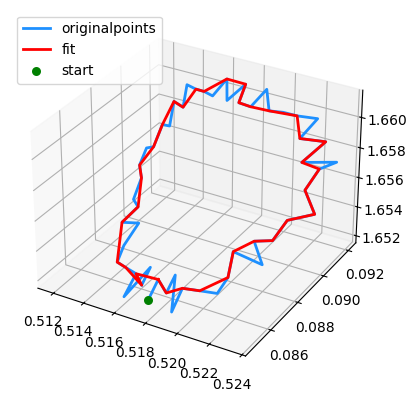

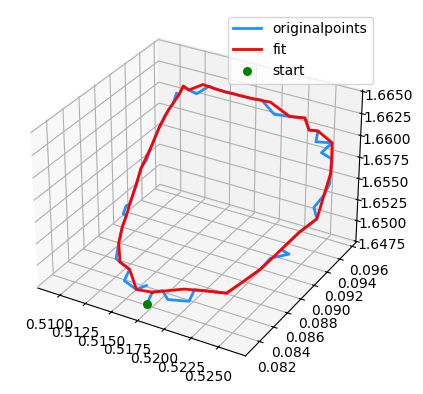

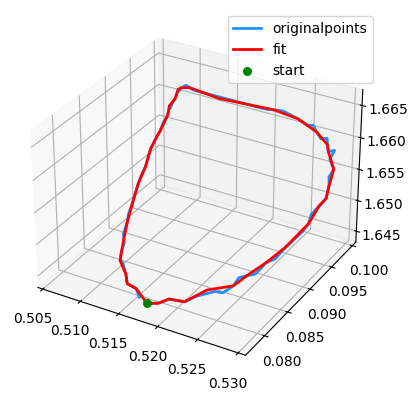

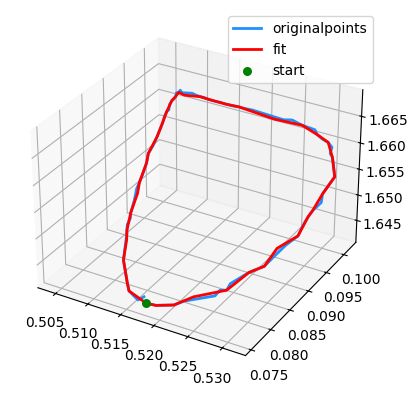

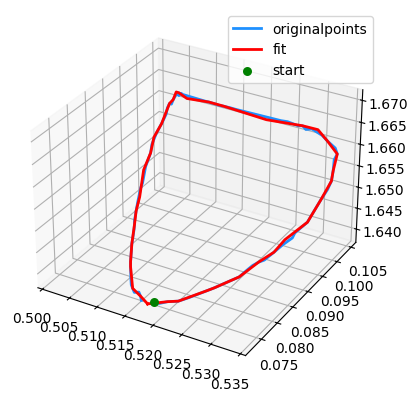

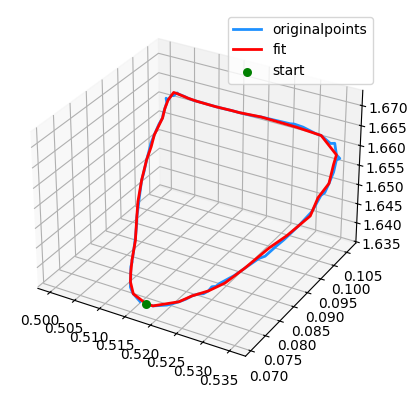

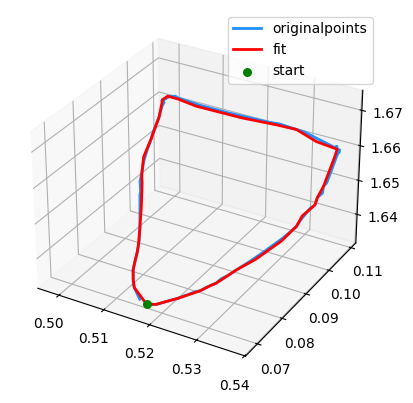

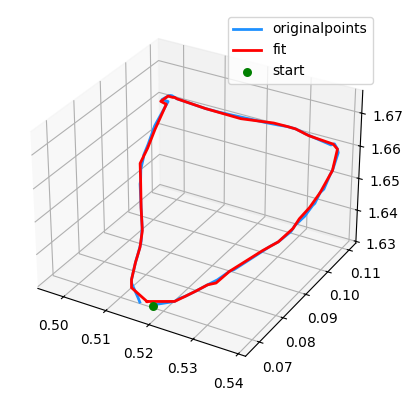

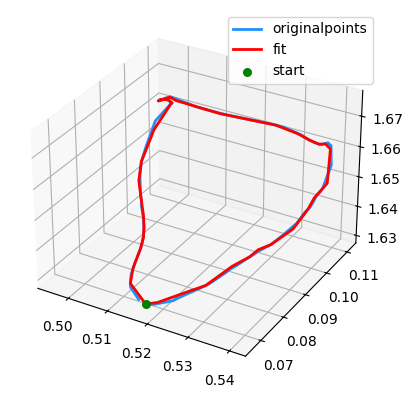

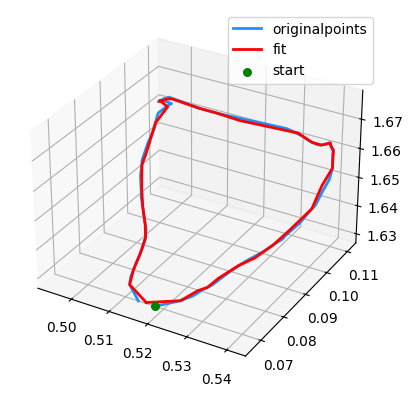

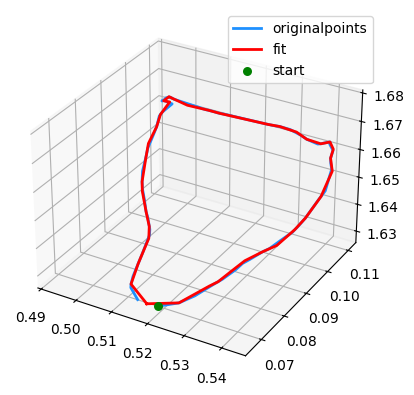

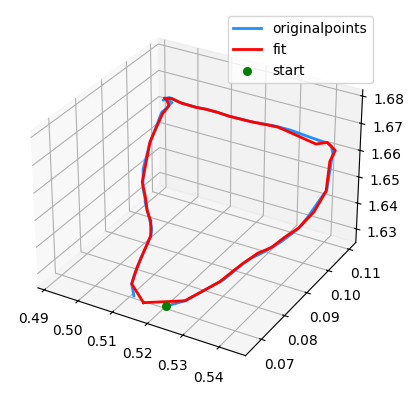

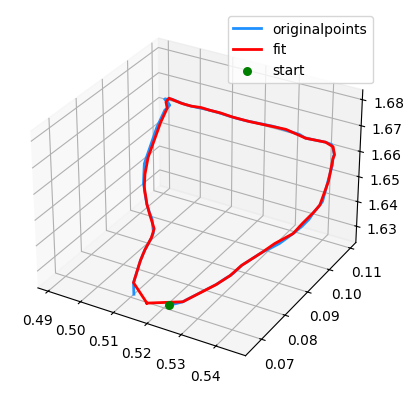

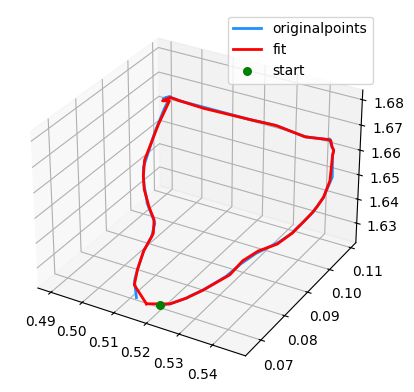

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

eye2eye_vec = np.array([-0.0392260253, -0.000119000673, 0.000252008438])
nose = np.array([0.517606, 0.067231, 1.632528])
d = np.dot(eye2eye_vec, nose)



df = pd.read_csv("../out/levelcurve_sorted_nose.csv",
                header = 0,
                low_memory=False
                )
data = df.to_numpy(dtype = np.double) #should be x,y,z and levelcurve_nr

df = pd.read_csv("../out/interpolated_curve_nose.csv",
                header = 0,
                low_memory=False
                )
data_interpolated = df.to_numpy(dtype = np.double) #should be levelcurve_r, x,y,z, min_curvature, max_curvature

nr_level_curves = int(np.max(data[:,3]))
for j in range(nr_level_curves):
    index = np.where(data[:,3] == j)[0]
    curve_data = data[index,0:3]

    index = np.where(data_interpolated[:,0] == j)[0]
    sampled = data_interpolated[index,1:4]

    miny_data = np.min(curve_data[:,1])
    maxy_data = np.max(curve_data[:,1])
    minz_data = np.min(curve_data[:,2])
    maxz_data = np.max(curve_data[:,2])
    y = np.linspace(miny_data, maxy_data, 100)
    z = np.linspace(minz_data, maxz_data, 100)
    yy,zz = np.meshgrid(y,z)
    x = (d - eye2eye_vec[1]*yy - eye2eye_vec[2]*zz)/eye2eye_vec[0]

    #now lets plot it!
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    #ax.plot_surface(x, yy, zz, alpha=0.5)
    ax.plot(curve_data[:,0], curve_data[:,1], curve_data[:,2], label='originalpoints', lw =2, c='Dodgerblue')
    ax.plot(sampled[:,0], sampled[:,1], sampled[:,2], label='fit', lw =2, c='red')
    ax.scatter(curve_data[0,0], curve_data[0,1], curve_data[0,2], label='start', lw =2, c='green')
    ax.legend()
plt.show()